# Neural network from scratch

In this notebook, I implement a neural network for multi-class classification without using any deep learning frameworks.

Chain rule calculations in a neural network involve several Jacobian matrices. In most cases, the full Jacobians contain many zeroes or duplicate numbers, so creating them implicitly instead of explicitly is more efficient. I provide two implementations using both implicit and explicit Jacobians.

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Latex

### Load data

In [2]:
X, y = load_iris(return_X_y=True)
one_hot = OneHotEncoder(sparse_output=False)
y_encoded = one_hot.fit_transform(y.reshape(-1, 1))
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded)

### Loss function

In [3]:
def log_sum_exp(x):
    # Add and subtract the max value of x for numerical stability
    c = x.max()
    return c + np.log(np.sum(np.exp(x - c)))

def cross_entropy_loss(y_pred_logits, y_true):
    # y_pred_logits should be a vector of logits (not probabilities).
    # y_true should be a one-hot vector.
    true_index = y_true.argmax()
    return -y_pred_logits[true_index] + log_sum_exp(y_pred_logits)

### Define model using implicit Jacobian matrices

In [4]:
class LinearImplicit:
    def __init__(self, input_size, output_size):
        rng = np.random.default_rng()

        self.input_size = input_size
        self.output_size = output_size

        self.W = rng.random((input_size, output_size))
        self.b = rng.random(output_size)
    
    def forward(self, x):
        self.input = x
        return x @ self.W + self.b

    def backward(self, dloss, learning_rate):
        dW = self.input # Implicit Jacobian
        dloss_dW = np.outer(dW, dloss)

        db = 1 # Implicit Jacobian
        dloss_db = db * dloss

        dloss = self.W @ dloss

        self.W -= learning_rate * dloss_dW
        self.b -= learning_rate * dloss_db

        return dloss

class ReLUImplicit:
    def forward(self, x):
        self.output = np.maximum(x, 0)
        return self.output

    def backward(self, dloss, learning_rate):
        drelu = (self.output > 0).astype("float") # Implicit Jacobian
        return drelu * dloss

class SoftmaxImplicit:
    def forward(self, x):
        shifted_x = x - x.max() # Subtract the max value of x for numerical stability
        exp_logits = np.exp(shifted_x)
        return exp_logits / exp_logits.sum()

    # A backward function isn't needed here for the implicit implementation.

class NeuralNetworkImplicit:
    def __init__(self, layers):
        self.layers = layers
    
    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        y_pred_logits = x
        softmax = SoftmaxImplicit()
        y_pred_probs = softmax.forward(x)
        return y_pred_logits, y_pred_probs

    def backward(self, y_pred_probs, y_true, learning_rate):
        dloss = y_pred_probs - y_true # combined derivative of both cross entropy and softmax
        for layer in reversed(self.layers):
            dloss = layer.backward(dloss, learning_rate)    

### Define model using explicit Jacobian matrices

In [5]:
class LinearExplicit:
    def __init__(self, input_size, output_size):
        rng = np.random.default_rng()

        self.input_size = input_size
        self.output_size = output_size

        self.W = rng.random((input_size, output_size))
        self.b = rng.random(output_size)
    
    def forward(self, x):
        self.input = x
        return x @ self.W + self.b

    def backward(self, dloss, learning_rate):
        dW = np.array([
            np.identity(self.output_size) * val
            for val in self.input
        ]) # Explicit Jacobian
        dloss_dW = dW @ dloss

        db = np.identity(self.output_size) # Explicit Jacobian
        dloss_db = db @ dloss

        dloss = self.W @ dloss

        self.W -= learning_rate * dloss_dW
        self.b -= learning_rate * dloss_db

        return dloss

class SoftmaxExplicit:
    def forward(self, x):
        shifted_x = x - x.max() # Subtract the max value of x for numerical stability
        exp_logits = np.exp(shifted_x)
        self.output =  exp_logits / exp_logits.sum()
        return self.output

    def backward(self, dloss, learning_rate):
        dsoftmax = np.array([
            [
                self.output[i] * (1 - self.output[i]) if i == j else -self.output[i] * self.output[j]
                for j in range(self.output.size)
            ]
            for i in range(self.output.size)
        ]) # Jacobian
        return dsoftmax @ dloss

class ReLUExplicit:
    def forward(self, x):
        self.output = np.maximum(x, 0)
        return self.output

    def backward(self, dloss, learning_rate):
        drelu = np.diag((self.output > 0).astype("float")) # Explicit Jacobian
        return drelu @ dloss

class NeuralNetworkExplicit:
    def __init__(self, layers):
        self.layers = layers
    
    def forward(self, x):
        for layer in self.layers[:-1]:
            x = layer.forward(x)
        y_pred_logits = x
        y_pred_probs = self.layers[-1].forward(x)
        return y_pred_logits, y_pred_probs

    def backward(self, y_pred, y_true, learning_rate):
        dloss = -y_true / y_pred
        for layer in reversed(self.layers):
            dloss = layer.backward(dloss, learning_rate)

### Train and test models

In [6]:
explicit_model = NeuralNetworkExplicit([
    LinearExplicit(4, 4),
    ReLUExplicit(),
    LinearExplicit(4, 3),
    SoftmaxExplicit(),
])

implicit_model = NeuralNetworkImplicit([
    LinearImplicit(4, 4),
    ReLUImplicit(),
    LinearImplicit(4, 3),
])

epochs = 50

explicit_train_losses = []
explicit_test_losses = []
explicit_train_accuracies = []
explicit_test_accuracies = []
implicit_train_losses = []
implicit_test_losses = []
implicit_train_accuracies = []
implicit_test_accuracies = []

def train(model, train_losses, train_accuracies):
    # Train
    loss = 0
    correct = 0
    for x, y in zip(X_train, y_train):
        y_pred_logits, y_pred_probs = model.forward(x)
        loss += cross_entropy_loss(y_pred_logits, y)
        classification = np.argmax(y_pred_probs)
        answer = np.argmax(y)
        if classification == answer:
            correct += 1
        model.backward(y_pred_probs, y, learning_rate=0.01)
    train_loss = loss / len(X_train)
    train_accuracy = correct / len(X_train)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    return train_loss, train_accuracy

def test(model, test_losses, test_accuracies):
    loss = 0
    correct = 0
    for x, y in zip(X_test, y_test):
        y_pred_logits, y_pred_probs = model.forward(x)
        loss += cross_entropy_loss(y_pred_logits, y)
        classification = np.argmax(y_pred_probs)
        answer = np.argmax(y)
        if classification == answer:
            correct += 1
    test_loss = loss / len(X_test)
    test_accuracy = correct / len(X_test)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)
    return test_loss, test_accuracy

def train_and_test(model, epochs, train_losses, test_losses, train_accuracies, test_accuracies):
    for epoch in range(epochs):
        train_loss, train_accuracy = train(model, train_losses, train_accuracies)
        test_loss, test_accuracy = test(model, test_losses, test_accuracies)
        if epoch % 10 == 9:
            print(f"Epoch {epoch + 1}/{epochs}")
            print(f"Training loss: {train_loss:.2f}")
            print(f"Training accuracy: {train_accuracy:.0%}")
            print(f"Testing loss: {test_loss:.2f}")
            print(f"Testing accuracy: {test_accuracy:.0%}")
            print()

In [7]:
train_and_test(
    explicit_model,
    epochs,
    explicit_train_losses,
    explicit_test_losses,
    explicit_train_accuracies,
    explicit_test_accuracies
)

Epoch 10/50
Training loss: 0.25
Training accuracy: 91%
Testing loss: 0.32
Testing accuracy: 84%

Epoch 20/50
Training loss: 0.13
Training accuracy: 96%
Testing loss: 0.19
Testing accuracy: 92%

Epoch 30/50
Training loss: 0.09
Training accuracy: 97%
Testing loss: 0.16
Testing accuracy: 95%

Epoch 40/50
Training loss: 0.07
Training accuracy: 99%
Testing loss: 0.16
Testing accuracy: 95%

Epoch 50/50
Training loss: 0.06
Training accuracy: 98%
Testing loss: 0.15
Testing accuracy: 97%



In [8]:
train_and_test(
    implicit_model,
    epochs,
    implicit_train_losses,
    implicit_test_losses,
    implicit_train_accuracies,
    implicit_test_accuracies
)

Epoch 10/50
Training loss: 0.21
Training accuracy: 94%
Testing loss: 0.27
Testing accuracy: 89%

Epoch 20/50
Training loss: 0.12
Training accuracy: 96%
Testing loss: 0.19
Testing accuracy: 95%

Epoch 30/50
Training loss: 0.08
Training accuracy: 97%
Testing loss: 0.16
Testing accuracy: 95%

Epoch 40/50
Training loss: 0.07
Training accuracy: 97%
Testing loss: 0.15
Testing accuracy: 95%

Epoch 50/50
Training loss: 0.06
Training accuracy: 97%
Testing loss: 0.15
Testing accuracy: 97%



### Visualize results

In [9]:
def plot(train_losses, test_losses, train_accuracies, test_accuracies, name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    fig.suptitle(name)

    ax1.set_title("Loss curve")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.plot(train_losses, label="Training loss")
    ax1.plot(test_losses, label="Testing loss")
    ax1.legend()

    ax2.set_title("Accuracy curve")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Accuracy")
    ax2.plot(train_accuracies, label="Training accuracy")
    ax2.plot(test_accuracies, label="Testing accuracy")
    ax2.legend()

    plt.show()

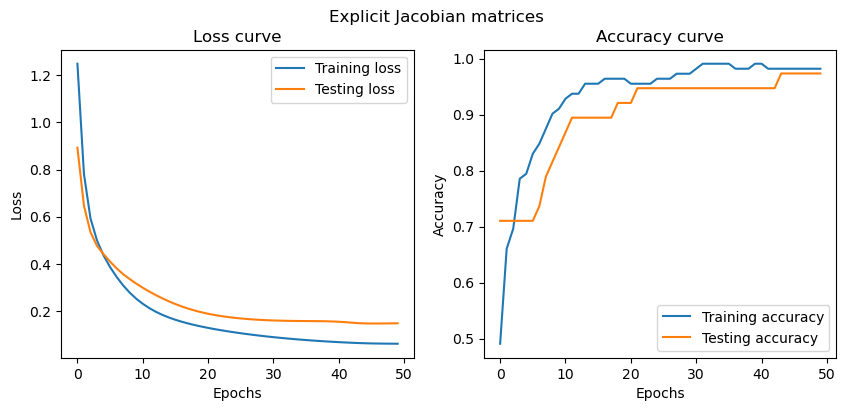

In [10]:
plot(
    explicit_train_losses,
    explicit_test_losses,
    explicit_train_accuracies,
    explicit_test_accuracies,
    "Explicit Jacobian matrices"
)

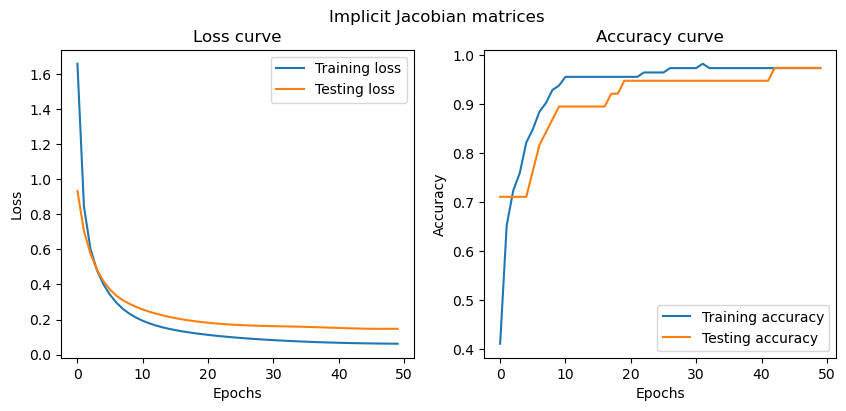

In [11]:
plot(
    implicit_train_losses,
    implicit_test_losses,
    implicit_train_accuracies,
    implicit_test_accuracies,
    "Implicit Jacobian matrices"
)

### Sources:
- https://web.stanford.edu/class/cs224n/readings/gradient-notes.pdf